## Import library

In [ ]:
import pandas as pd 
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt


## Import Dataset

In [26]:
# df = pd.read_csv('marketing_campaign.csv',sep='\t')
df = pd.read_csv('marketing_compaign_cleaned.csv')

quan_col = df.select_dtypes('object')
quan_col.columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

Are certain education levels associated with specific marital statuses?

Which categories drive the association?

H0: Education level and marital status are independent (no association).
H1: Education level and marital status are not independent (there is an association).
	​


In [28]:
df_ca = df[['Education', 'Marital_Status']].dropna()

In [29]:
# Create contingency table
ct = pd.crosstab(df_ca['Education'], df_ca['Marital_Status'])
ct


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,0,0,22,81,36,57,5,0
Basic,0,0,1,20,18,14,1,0
Graduation,1,1,116,432,249,284,35,0
Master,1,1,37,138,74,105,12,0
PhD,0,1,52,188,96,113,24,2


In [30]:
# Chi-square Education vs Marital_Status

# Two category columns 

df_ca1 = df[["Education", "Marital_Status"]].dropna()

# 1) Hypotheses teating

print("H0: Education level and marital status are independent (no association).")
print("H1: Education level and marital status are not independent (there is an association).")

# 2) Contingency table

ct = pd.crosstab(df_ca1["Education"], df_ca1["Marital_Status"])
print("\nContingency table (Observed counts):")
print(ct)

# 3) Chi-square test

chi2, p_value, dof, expected = chi2_contingency(ct.values)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print("\nChi-square test results:")
print(f"  chi2 statistic = {chi2:.4f}")
print(f"  dof            = {dof}")
print(f"  p-value        = {p_value:.6g}")

alpha = 0.05
decision = "REJECT H0 (associated)" if p_value <= alpha else "FAIL TO REJECT H0 (independent)"
print(f"  Decision @ alpha={alpha}: {decision}")

# Assumptions check (expected counts)

min_expected = expected_df.to_numpy().min()
pct_ge_5 = (expected_df.to_numpy() >= 5).mean() * 100
print("\nAssumptions check:")
print(f"  Min expected count: {min_expected:.2f}")
print(f"  % cells with expected >= 5: {pct_ge_5:.1f}%")

#  Correspondence Analysis (CA) + symmetric biplot
#    Run CA only if association is significant (p <= 0.05)
if p_value <= alpha:
    N = ct.to_numpy(dtype=float)
    n = N.sum()

    P = N / n
    r = P.sum(axis=1, keepdims=True)
    c = P.sum(axis=0, keepdims=True)

    Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r.ravel()))
    Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c.ravel()))

    S = Dr_inv_sqrt @ (P - r @ c) @ Dc_inv_sqrt
    U, s, Vt = np.linalg.svd(S, full_matrices=False)

    eig = s**2
    explained = eig / eig.sum()

    k = 2
    Sigma_half = np.diag(np.sqrt(s[:k]))

    # symmetric map
    F = Dr_inv_sqrt @ U[:, :k] @ Sigma_half  # rows (Education)
    G = Dc_inv_sqrt @ Vt.T[:, :k] @ Sigma_half  # cols (Marital_Status)

    # Plot symmetric biplot
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(F[:, 0], F[:, 1], marker="o", label="Rows: Education")
    for (x, y), lab in zip(F, ct.index.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.scatter(G[:, 0], G[:, 1], marker="^", label="Cols: Marital_Status")
    for (x, y), lab in zip(G, ct.columns.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel(f"Dim 1 ({explained[0]*100:.1f}%)")
    ax.set_ylabel(f"Dim 2 ({explained[1]*100:.1f}%)")
    ax.set_title("Correspondence Analysis (Symmetric Biplot): Education vs Marital_Status")
    ax.legend()
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    # Distance tables (DataFrames)
    row_distance_table = pd.DataFrame({
        "Education": ct.index,
        "Dim1": F[:, 0],
        "Dim2": F[:, 1],
        "Distance_from_origin": np.sqrt(F[:, 0]**2 + F[:, 1]**2)
    }).set_index("Education").sort_values("Distance_from_origin", ascending=False)

    col_distance_table = pd.DataFrame({
        "Marital_Status": ct.columns,
        "Dim1": G[:, 0],
        "Dim2": G[:, 1],
        "Distance_from_origin": np.sqrt(G[:, 0]**2 + G[:, 1]**2)
    }).set_index("Marital_Status").sort_values("Distance_from_origin", ascending=False)

    print("\nDistance from origin – ROWS (Education):")
    print(row_distance_table.round(4))

    print("\nDistance from origin – COLUMNS (Marital_Status):")
    print(col_distance_table.round(4))

else:
    print("\nCA skipped because chi-square test is not significant (p > 0.05).")


H0: Education level and marital status are independent (no association).
H1: Education level and marital status are not independent (there is an association).

Contingency table (Observed counts):
Marital_Status  Absurd  Alone  Divorced  Married  Single  Together  Widow  \
Education                                                                   
2n Cycle             0      0        22       81      36        57      5   
Basic                0      0         1       20      18        14      1   
Graduation           1      1       116      432     249       284     35   
Master               1      1        37      138      74       105     12   
PhD                  0      1        52      188      96       113     24   

Marital_Status  YOLO  
Education             
2n Cycle           0  
Basic              0  
Graduation         0  
Master             0  
PhD                2  

Chi-square test results:
  chi2 statistic = 27.9250
  dof            = 28
  p-value        = 0.468429

## CA2 Education Level vs Number of Children
- Ho: Education level and number of children are independent

In [31]:
# Chi-square Education vs Number of Children (Kids_cat) + optional CA

# -----------------------------
# 0) Create "Kids" and kids category
# -----------------------------
df = df.copy()
df['Kids'] = df['Kidhome'] + df['Teenhome']

df['Kids_cat'] = pd.cut(
    df['Kids'],
    bins=[-1, 0, 1, 2, df['Kids'].max()],
    labels=['No Kids', 'One Kid', 'Two Kids', 'Three+ Kids']
)

# -----------------------------
# 1) Data for test
# -----------------------------
df_ca2 = df[['Education', 'Kids_cat']].dropna()

print("H0: Education level and number of children are independent (no association).")
print("H1: Education level and number of children are not independent (there is an association).")

# -----------------------------
# 2) Contingency table
# -----------------------------
ct = pd.crosstab(df_ca2['Education'], df_ca2['Kids_cat'])
print("\nContingency table (Observed counts):")
print(ct)

# -----------------------------
# 3) Chi-square test
# -----------------------------
chi2, p_value, dof, expected = chi2_contingency(ct.values)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print("\nChi-square test results:")
print(f"  chi2 statistic = {chi2:.4f}")
print(f"  dof            = {dof}")
print(f"  p-value        = {p_value:.6g}")

alpha = 0.05
decision = "REJECT H0 (associated)" if p_value <= alpha else "FAIL TO REJECT H0 (independent)"
print(f"  Decision @ alpha={alpha}: {decision}")

# -----------------------------
# 4) Assumptions check
# -----------------------------
min_expected = expected_df.to_numpy().min()
pct_ge_5 = (expected_df.to_numpy() >= 5).mean() * 100

print("\nAssumptions check:")
print(f"  Min expected count: {min_expected:.2f}")
print(f"  % cells with expected >= 5: {pct_ge_5:.1f}%")

# -----------------------------
# 5) (Optional) Correspondence Analysis (CA)
# -----------------------------
if p_value <= alpha:
    N = ct.to_numpy(dtype=float)
    n = N.sum()

    P = N / n
    r = P.sum(axis=1, keepdims=True)
    c = P.sum(axis=0, keepdims=True)

    Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r.ravel()))
    Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c.ravel()))

    S = Dr_inv_sqrt @ (P - r @ c) @ Dc_inv_sqrt
    U, s, Vt = np.linalg.svd(S, full_matrices=False)

    eig = s**2
    explained = eig / eig.sum()

    k = 2
    Sigma_half = np.diag(np.sqrt(s[:k]))

    # symmetric map
    F = Dr_inv_sqrt @ U[:, :k] @ Sigma_half      # rows: Education
    G = Dc_inv_sqrt @ Vt.T[:, :k] @ Sigma_half   # cols: Kids_cat

    # Plot symmetric biplot
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(F[:, 0], F[:, 1], marker="o", label="Rows: Education")
    for (x, y), lab in zip(F, ct.index.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.scatter(G[:, 0], G[:, 1], marker="^", label="Cols: Number of Children")
    for (x, y), lab in zip(G, ct.columns.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel(f"Dim 1 ({explained[0]*100:.1f}%)")
    ax.set_ylabel(f"Dim 2 ({explained[1]*100:.1f}%)")
    ax.set_title("Correspondence Analysis (Symmetric Biplot): Education vs Number of Children")
    ax.legend()
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    # Distance tables
    row_distance_table = pd.DataFrame({
        "Education": ct.index,
        "Dim1": F[:, 0],
        "Dim2": F[:, 1],
        "Distance_from_origin": np.sqrt(F[:, 0]**2 + F[:, 1]**2)
    }).set_index("Education").sort_values("Distance_from_origin", ascending=False)

    col_distance_table = pd.DataFrame({
        "Kids_cat": ct.columns,
        "Dim1": G[:, 0],
        "Dim2": G[:, 1],
        "Distance_from_origin": np.sqrt(G[:, 0]**2 + G[:, 1]**2)
    }).set_index("Kids_cat").sort_values("Distance_from_origin", ascending=False)

    print("\nDistance from origin – ROWS (Education):")
    print(row_distance_table.round(4))

    print("\nDistance from origin – COLUMNS (Number of Children):")
    print(col_distance_table.round(4))

else:
    print("\nCA skipped because chi-square test is not significant (p > 0.05).")


H0: Education level and number of children are independent (no association).
H1: Education level and number of children are not independent (there is an association).

Contingency table (Observed counts):
Kids_cat    No Kids  One Kid  Two Kids  Three+ Kids
Education                                          
2n Cycle         64       99        35            3
Basic            17       35         2            0
Graduation      316      575       202           25
Master          101      177        82            8
PhD             130      233        96           17

Chi-square test results:
  chi2 statistic = 19.2776
  dof            = 12
  p-value        = 0.0820449
  Decision @ alpha=0.05: FAIL TO REJECT H0 (independent)

Assumptions check:
  Min expected count: 1.29
  % cells with expected >= 5: 90.0%

CA skipped because chi-square test is not significant (p > 0.05).


## CA3: Kids vs Marital_Stetus

H0: Kids category and marital status are independent (no association).
H1: Kids category and marital status are not independent (there is an association).

Contingency table (Observed counts):
Marital_Status  Absurd  Alone  Divorced  Married  Single  Together  Widow  \
Kids_cat                                                                    
No Kids              2      0        55      228     164       152     27   
One Kid              0      1       119      447     221       296     33   
Two Kids             0      2        49      167      72       110     17   
Three+ Kids          0      0         5       17      16        15      0   

Marital_Status  YOLO  
Kids_cat              
No Kids            0  
One Kid            2  
Two Kids           0  
Three+ Kids        0  

Chi-square test results:
  chi2 statistic = 35.0164
  dof            = 21
  p-value        = 0.0281184
  Decision @ alpha=0.05: REJECT H0 (associated)

Assumptions check:
  Min expected count: 0.05
  % cel

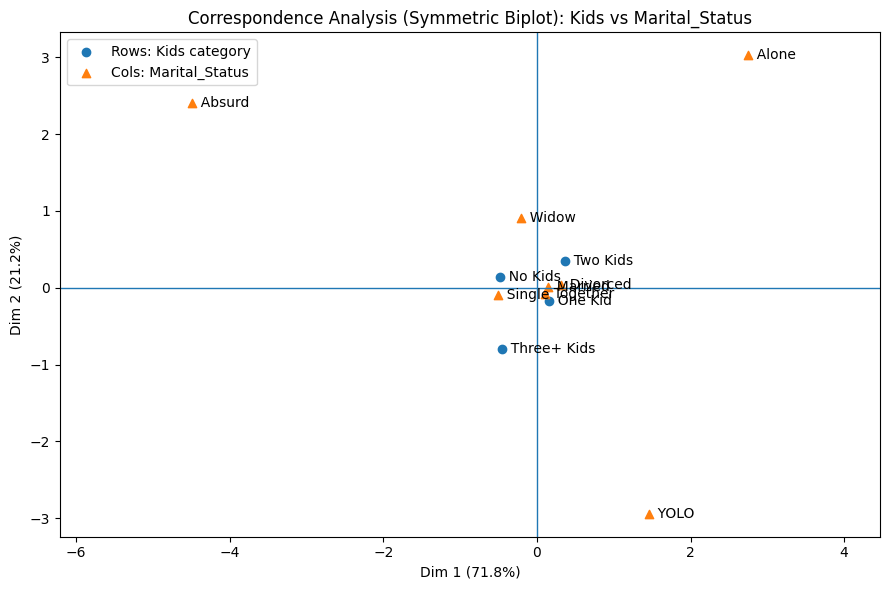


Distance from origin – ROWS (Kids categories):
               Dim1    Dim2  Distance_from_origin
Kids_cat                                         
Three+ Kids -0.4529 -0.7913                0.9118
Two Kids     0.3613  0.3480                0.5016
No Kids     -0.4785  0.1392                0.4983
One Kid      0.1553 -0.1703                0.2305

Distance from origin – COLUMNS (Marital_Status):
                  Dim1    Dim2  Distance_from_origin
Marital_Status                                      
Absurd         -4.4935  2.4043                5.0963
Alone           2.7481  3.0278                4.0890
YOLO            1.4589 -2.9426                3.2844
Widow          -0.2013  0.9095                0.9315
Single         -0.5038 -0.0884                0.5115
Divorced        0.3134  0.0366                0.3155
Married         0.1419  0.0054                0.1420
Together        0.1016 -0.0858                0.1330


In [ ]:
# Chi-square Kids (Kids_cat) vs Marital_Status + optional Correspondence Analysis (CA)

# -----------------------------
# 0) Create Kids and Kids_cat
# -----------------------------
df = df.copy()
df['Kids'] = df['Kidhome'] + df['Teenhome']

df['Kids_cat'] = pd.cut(
    df['Kids'],
    bins=[-1, 0, 1, 2, df['Kids'].max()],
    labels=['No Kids', 'One Kid', 'Two Kids', 'Three+ Kids']
)

# -----------------------------
# 1) Data for test
# -----------------------------
df_ca = df[['Kids_cat', 'Marital_Status']].dropna()

print("H0: Kids category and marital status are independent (no association).")
print("H1: Kids category and marital status are not independent (there is an association).")

# -----------------------------
# 2) Contingency table
# -----------------------------
ct = pd.crosstab(df_ca['Kids_cat'], df_ca['Marital_Status'])
print("\nContingency table (Observed counts):")
print(ct)

# -----------------------------
# 3) Chi-square test
# -----------------------------
chi2, p_value, dof, expected = chi2_contingency(ct.values)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print("\nChi-square test results:")
print(f"  chi2 statistic = {chi2:.4f}")
print(f"  dof            = {dof}")
print(f"  p-value        = {p_value:.6g}")

alpha = 0.05
decision = "REJECT H0 (associated)" if p_value <= alpha else "FAIL TO REJECT H0 (independent)"
print(f"  Decision @ alpha={alpha}: {decision}")

# -----------------------------
# 4) Assumptions check
# -----------------------------
min_expected = expected_df.to_numpy().min()
pct_ge_5 = (expected_df.to_numpy() >= 5).mean() * 100

print("\nAssumptions check:")
print(f"  Min expected count: {min_expected:.2f}")
print(f"  % cells with expected >= 5: {pct_ge_5:.1f}%")

# -----------------------------
# 5) (Optional) Correspondence Analysis (CA)
# -----------------------------
if p_value <= alpha:
    N = ct.to_numpy(dtype=float)
    n = N.sum()

    P = N / n
    r = P.sum(axis=1, keepdims=True)
    c = P.sum(axis=0, keepdims=True)

    Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r.ravel()))
    Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c.ravel()))

    S = Dr_inv_sqrt @ (P - r @ c) @ Dc_inv_sqrt
    U, s, Vt = np.linalg.svd(S, full_matrices=False)

    eig = s**2
    explained = eig / eig.sum()

    k = 2
    Sigma_half = np.diag(np.sqrt(s[:k]))

    # symmetric map
    F = Dr_inv_sqrt @ U[:, :k] @ Sigma_half       # rows: Kids_cat
    G = Dc_inv_sqrt @ Vt.T[:, :k] @ Sigma_half    # cols: Marital_Status

    # Plot symmetric biplot
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(F[:, 0], F[:, 1], marker="o", label="Rows: Kids category")
    for (x, y), lab in zip(F, ct.index.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.scatter(G[:, 0], G[:, 1], marker="^", label="Cols: Marital_Status")
    for (x, y), lab in zip(G, ct.columns.astype(str)):
        ax.text(x, y, f"  {lab}", va="center")

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel(f"Dim 1 ({explained[0]*100:.1f}%)")
    ax.set_ylabel(f"Dim 2 ({explained[1]*100:.1f}%)")
    ax.set_title("Correspondence Analysis (Symmetric Biplot): Kids vs Marital_Status")
    ax.legend()
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

    # Distance from origin tables
    row_distance_table = pd.DataFrame({
        "Kids_cat": ct.index,
        "Dim1": F[:, 0],
        "Dim2": F[:, 1],
        "Distance_from_origin": np.sqrt(F[:, 0]**2 + F[:, 1]**2)
    }).set_index("Kids_cat").sort_values("Distance_from_origin", ascending=False)

    col_distance_table = pd.DataFrame({
        "Marital_Status": ct.columns,
        "Dim1": G[:, 0],
        "Dim2": G[:, 1],
        "Distance_from_origin": np.sqrt(G[:, 0]**2 + G[:, 1]**2)
    }).set_index("Marital_Status").sort_values("Distance_from_origin", ascending=False)

    print("\nDistance from origin – ROWS (Kids categories):")
    print(row_distance_table.round(4))

    print("\nDistance from origin – COLUMNS (Marital_Status):")
    print(col_distance_table.round(4))

else:
    print("\nCA skipped because chi-square test is not significant (p > 0.05).")


- The first two dimensions explain most of the association (Dim 1 = 71.7%, Dim 2 = 21.3%).

- Married and Together are closely associated with Two Kids / Three+ Kids, indicating family-oriented households.

- Single and Widow are located near No Kids / One Kid, suggesting childless or smaller households.

- Rare categories (YOLO, Alone, Absurd) are far from the origin, showing distinct but uncommon profiles that should be interpreted cautiously.